<a href="https://colab.research.google.com/github/melihaslan233-glitch/Water-Quality-data-/blob/main/waterqualitySAMSUNG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [725]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [726]:
import pandas as pd

pd.options.display.float_format = '{:.2f}'.format #displaying float numbers with 2 decimal places

df = pd.read_csv('/content/drive/MyDrive/water_potability.csv')

df.head() # gives us first five rows

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.89,20791.32,7.30,368.52,564.31,10.38,86.99,2.96,0
1,3.72,129.42,18630.06,6.64,NaN,592.89,15.18,56.33,4.50,0
2,8.10,224.24,19909.54,9.28,NaN,418.61,16.87,66.42,3.06,0
3,8.32,214.37,22018.42,8.06,356.89,363.27,18.44,100.34,4.63,0
4,9.09,181.10,17978.99,6.55,310.14,398.41,11.56,32.00,4.08,0


In [727]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


# Missing Values

In [728]:
df.isnull().sum() # Checking for missing values

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [729]:
# printing missing values
print(f"\nTotal missing: {df.isnull().sum().sum()} values")


Total missing: 1434 values



# Filling missing values with column mean (excluding potability)


In [730]:
features = df.drop(columns=['Potability']).columns
df[features] = df[features].fillna(df[features].mean())

In [731]:
# Checking missing values
print("Missing values after filling with mean")
print(df.isnull().sum())

Missing values after filling with mean
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


# Plotting potability

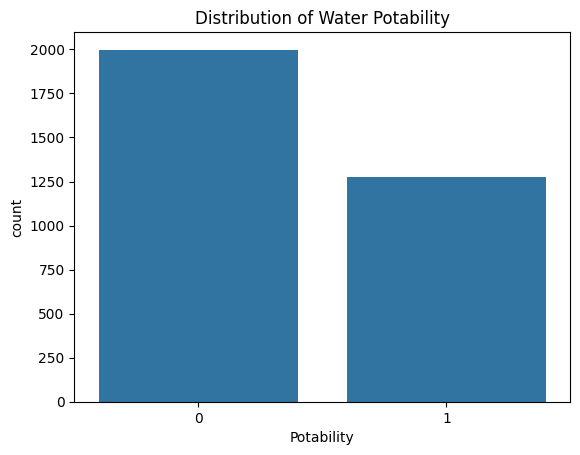

In [732]:
sns.countplot(x='Potability', data=df)
plt.title("Distribution of Water Potability")
plt.show()

# Most of the water is not drinkable

# Correlation Matrix of Potability

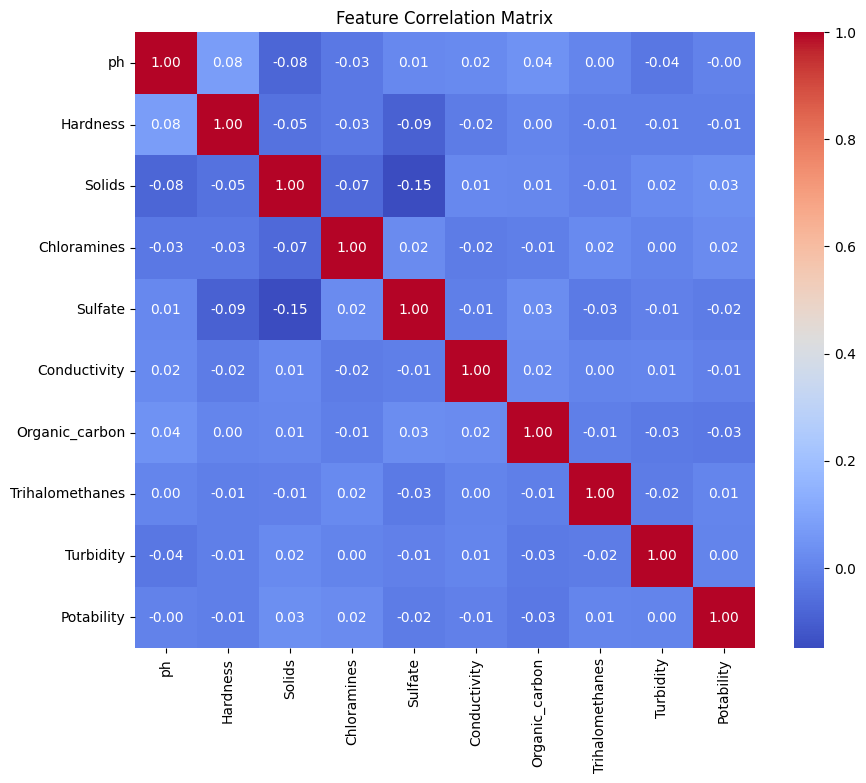

In [733]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True,fmt='.2f',cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()
# fmt='.2f' Stops the numbers two decimal places

# Loading World Bank water stress data

In [734]:
df_wb = pd.read_csv('/content/drive/MyDrive/API_ER.H2O.FWST.ZS_DS2_en_csv_v2_3317.csv', skiprows=4)


In [735]:
# We will keep only country level rows and year 2020
df_wb_2020 = df_wb[['Country Name', 'Country Code', '2020']].copy()
df_wb_2020.columns = ['Country', 'Code', 'Water_Stress_2020']
df_wb_2020 = df_wb_2020.dropna(subset=['Water_Stress_2020'])

print(f"World Bank: {len(df_wb_2020)} countries with 2020 water stress data")
df_wb_2020.head()

World Bank: 178 countries with 2020 water stress data


,Country,Code,Water_Stress_2020
2,Afghanistan,AFG,54.76
4,Angola,AGO,1.87
5,Albania,ALB,4.72
8,United Arab Emirates,ARE,1587.33
9,Argentina,ARG,10.46


In [736]:
# List of all valid Country Codes from World Bank data set
country_codes = df_wb_2020['Code'].unique()

# Synthetic Assignment (randomly assigning a country code to every water sample)
# random seed (42) so it generates the exact same way every time we run it
np.random.seed(42)
df['Code'] = np.random.choice(country_codes, size=len(df))

# Merging: Now  both datasets have a Code column
df_merged = pd.merge(df, df_wb_2020, on='Code', how='inner')

print(f"The dataset has {len(df_merged)} rows and {len(df_merged.columns)} columns.")
display(df_merged.head())

The dataset has 3276 rows and 13 columns.


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,Code,Country,Water_Stress_2020
0,7.08,204.89,20791.32,7.30,368.52,564.31,10.38,86.99,2.96,0,MDA,Moldova,12.56
1,3.72,129.42,18630.06,6.64,333.78,592.89,15.18,56.33,4.50,0,LBN,Lebanon,58.79
2,8.10,224.24,19909.54,9.28,333.78,418.61,16.87,66.42,3.06,0,BGD,Bangladesh,5.72
3,8.32,214.37,22018.42,8.06,356.89,363.27,18.44,100.34,4.63,0,MKD,North Macedonia,34.85
4,9.09,181.10,17978.99,6.55,310.14,398.41,11.56,32.00,4.08,0,HTI,Haiti,13.38


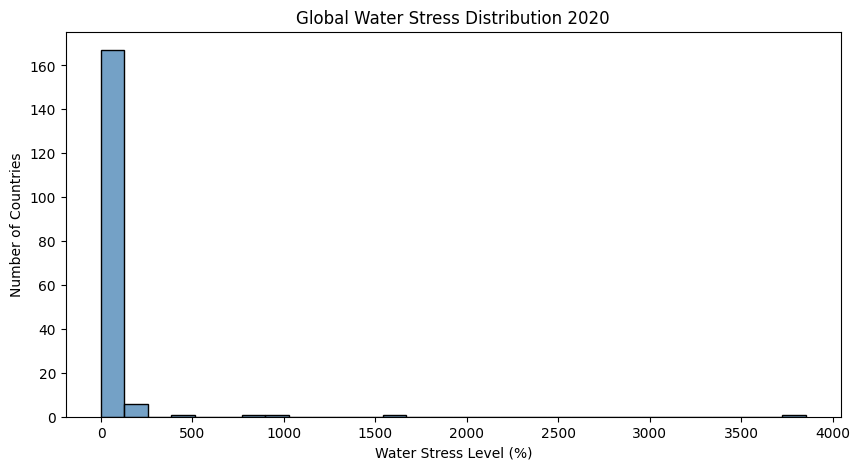

In [737]:
plt.figure(figsize=(10,5))
sns.histplot(df_wb_2020['Water_Stress_2020'], bins=30, color='steelblue')
plt.title("Global Water Stress Distribution 2020")
plt.xlabel("Water Stress Level (%)")
plt.ylabel("Number of Countries")
plt.show()

# our model is designed to detect whether water is safe to consume in these high stress regions on the right

In [738]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)

# features
X = df_merged.drop(columns=['Potability', 'Country', 'Code'])

# target (0 = not drinkable, 1 = drinkable)
y = df_merged['Potability']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalising features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 2620
Test samples:     656


In [739]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)


# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))

Random Forest Accuracy: 0.6844512195121951
Logistic Regression Accuracy: 0.6280487804878049


In [740]:
for name, model in [("Random Forest", rf), ("Logistic Regression", lr)]:
    y_pred = model.predict(X_test_scaled)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred,
          target_names=["Not Potable", "Potable"]))


Random Forest
              precision    recall  f1-score   support

 Not Potable       0.69      0.90      0.78       412
     Potable       0.66      0.32      0.43       244

    accuracy                           0.68       656
   macro avg       0.67      0.61      0.60       656
weighted avg       0.68      0.68      0.65       656


Logistic Regression
              precision    recall  f1-score   support

 Not Potable       0.63      1.00      0.77       412
     Potable       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


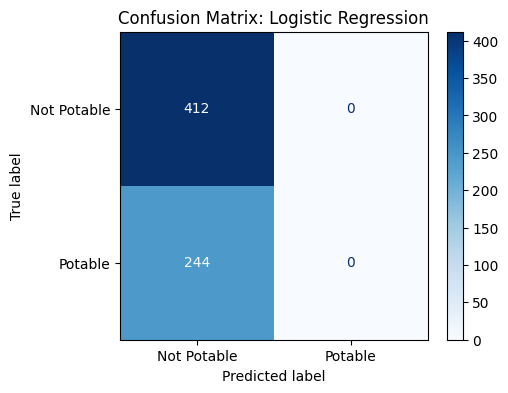

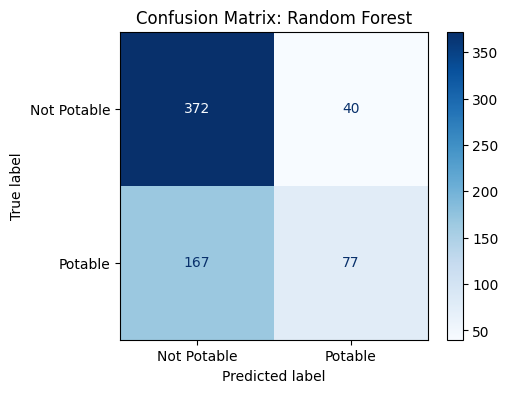

In [741]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Potable", "Potable"])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title(f"Confusion Matrix: Logistic Regression")
plt.show()


cm_rf = confusion_matrix(y_test, rf_preds)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Not Potable", "Potable"])
fig, ax = plt.subplots(figsize=(5, 4))
disp_rf.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix: Random Forest")
plt.show()

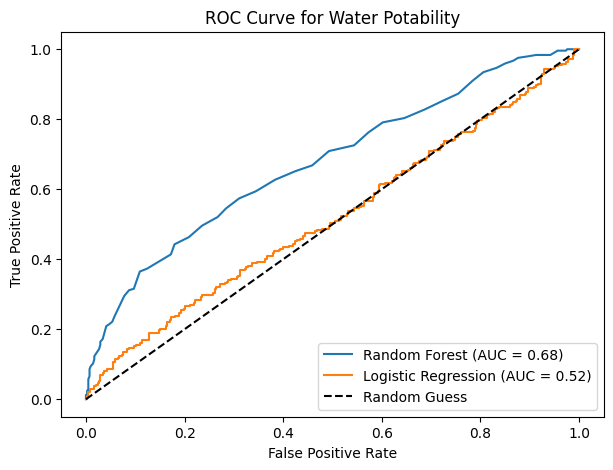

In [742]:
# ROC CURVE

fig, ax = plt.subplots(figsize=(7, 5))

for model, name in [(rf, 'Random Forest'), (lr, 'Logistic Regression')]:
    probs = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve for Water Potability')
ax.legend(loc="lower right")
plt.savefig('roc_curve.png', dpi=150)
plt.show()